In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
idx = pd.IndexSlice

In [14]:
bal = pd.read_csv(
    Path.cwd().parent  / 'results' / 'csvs' / 'energy_balance.csv', header=list(range(5)), index_col=[0,1,2]
)
bal.columns = bal.columns.get_level_values(-1).astype(int)
bal.head()

wiggle                                                  0             250   \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.918550e+08  2.563997e+08   
          Offshore Wind (DC)       AC           3.010948e+08  2.839668e+08   
          Offshore Wind (Floating) AC           7.469356e+02  6.748944e+02   
          Onshore Wind             AC           1.024939e+09  1.034054e+09   
          Run of River             AC           1.605181e+08  1.605832e+08   

wiggle                                                  500           750   \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.420462e+08  2.363675e+08   
          Offshore Wind (DC)       AC           2.764314e+08  2.588663e+08   
          Offshore Wind (Floating) AC           2.774986e+02  4.615355e+02   
          Onshore Wind             AC           9.627309e+08  8.774669e+08   
          Run of River             AC           1.610183e+08  1.608973e+08   

wiggle                                                  1000          1250  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.357253e+08  2.363496e+08   
          Offshore Wind (DC)       AC           2.287777e+08  2.250767e+08   
          Offshore Wind (Floating) AC           6.642749e+02  4.735964e+02   
          Onshore Wind             AC           8.418261e+08  7.996371e+08   
          Run of River             AC           1.613242e+08  1.617309e+08   

wiggle                                                  1500          1750  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.314669e+08  2.367359e+08   
          Offshore Wind (DC)       AC           2.297178e+08  2.222453e+08   
          Offshore Wind (Floating) AC           7.106848e+02  6.935899e+02   
          Onshore Wind             AC           7.736297e+08  7.394033e+08   
          Run of River             AC           1.619653e+08  1.619542e+08   

wiggle                                                  2000          2250  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.356687e+08  2.352737e+08   
          Offshore Wind (DC)       AC           2.132387e+08  2.068756e+08   
          Offshore Wind (Floating) AC           6.936563e+02  5.055282e+02   
          Onshore Wind             AC           7.108103e+08  6.888042e+08   
          Run of River             AC           1.618019e+08  1.618685e+08   

wiggle                                          ...          2750  \
component carrier                  bus_carrier  ...                 
Generator Offshore Wind (AC)       AC           ...  2.275130e+08   
          Offshore Wind (DC)       AC           ...  1.621367e+08   
          Offshore Wind (Floating) AC           ...  2.864092e+02   
          Onshore Wind             AC           ...  6.443047e+08   
          Run of River             AC           ...  1.620468e+08   

wiggle                                                  3000          3250  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.303645e+08  2.320342e+08   
          Offshore Wind (DC)       AC           1.312410e+08  8.509936e+07   
          Offshore Wind (Floating) AC           5.997836e+02  3.091148e+02   
          Onshore Wind             AC           6.251590e+08  6.210625e+08   
          Run of River             AC           1.622232e+08  1.623575e+08   

wiggle                                                  3500          3750  \
component carrier                  bus_carrier                               
Generator Offshore Wind (AC)       AC           2.289933e+08  2.166289e+08   


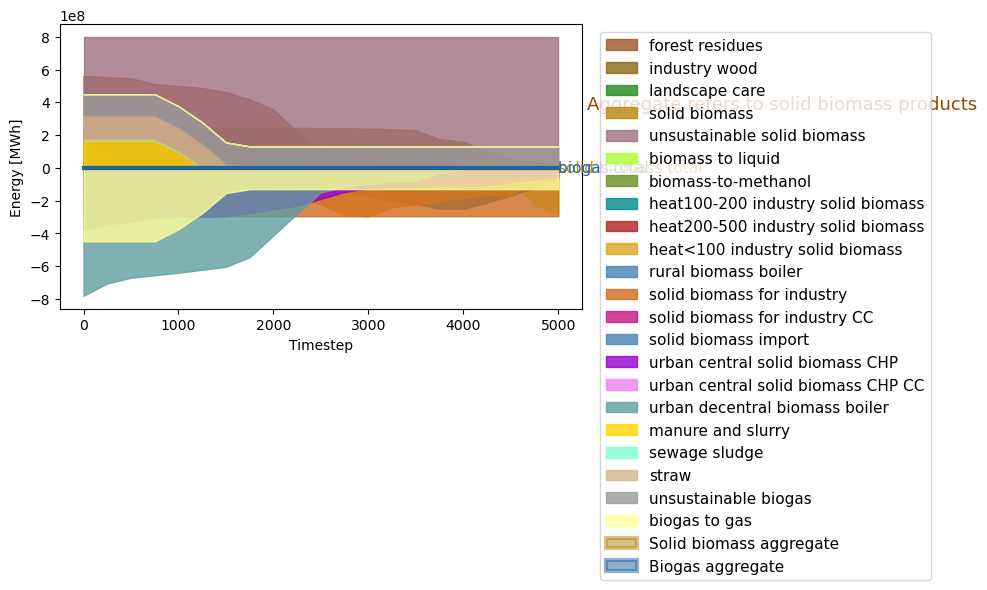

In [21]:
# Define your color dictionary beforehand or import as required
# Example/demonstration color dict:
tech_colors = {
    'forest residues': '#A0522D',
    'industry wood': '#8B6914',
    'landscape care': '#228B22',
    'solid biomass': '#B8860B',
    'unsustainable solid biomass': '#a07080',
    'biomass to liquid': '#ADFF2F',
    'biomass-to-methanol': '#6B8E23',
    'heat100-200 industry solid biomass': '#008B8B',
    'heat200-500 industry solid biomass': '#B22222',
    'heat<100 industry solid biomass': '#DAA520',
    'rural biomass boiler': '#4682B4',
    'solid biomass for industry': '#D2691E',
    'solid biomass for industry CC': '#C71585',
    'solid biomass import': '#4682b4',
    'urban central solid biomass CHP': '#9400D3',
    'urban central solid biomass CHP CC': '#EE82EE',
    'urban decentral biomass boiler': '#5F9EA0',

    'manure and slurry': '#FFD700',
    'sewage sludge': '#7FFFD4',
    'straw': '#D2B48C',
    'unsustainable biogas': '#999999',
    'biogas to gas': '#ffff99',
    # Add other techs as necessary
    'biogas_agg': '#20639B',
    'solid_biomass_agg': '#B8860B'
}

fig, ax = plt.subplots(figsize=(10, 5))

# 1. Solid biomass selection
bm_idx = 'solid biomass'
df_bm = bal.loc[idx[:, :, bm_idx]]

# Drop level 0 (component); keep level 1 (carrier)
df_bm = df_bm.droplevel(0)
# Prepare for stacking pos/neg split
df_bm_pos = df_bm.clip(lower=0)
df_bm_neg = df_bm.clip(upper=0)

# Plot positive values
handles = []
labels = []
for tech in df_bm_pos.index.unique(0):
    data = df_bm_pos.loc[tech]
    color = tech_colors.get(tech, None)
    h = ax.fill_between(
        df_bm_pos.columns, 
        data.values, 
        0, 
        label=tech, 
        color=color, 
        alpha=0.8
    )
    handles.append(h)
    labels.append(tech)

# Plot negative values separately
for tech in df_bm_neg.index.unique(0):
    data = df_bm_neg.loc[tech]
    color = tech_colors.get(tech, None)
    h = ax.fill_between(
        df_bm_neg.columns, 
        0, 
        data.values, 
        label=None, # don't double-add legend
        color=color, 
        alpha=0.8
    )

# Aggregate solid biomass: sum among all level 1 index
agg_bm = df_bm.sum(axis=0)

ax.plot(
    agg_bm.index, 
    agg_bm.values, 
    color=tech_colors.get('solid_biomass_agg', 'k'), 
    lw=3, 
    label="Solid biomass aggregate"
)
ax.fill_between(
    agg_bm.index, 
    agg_bm.values, 
    0, 
    color=tech_colors.get('solid_biomass_agg', '#B8860B'), 
    alpha=0.18, 
    zorder=1
)

# Label
ax.text(
    agg_bm.index[-1], 
    agg_bm.values[-1], 
    "solid biomass total", 
    va='center', 
    ha='left', 
    fontsize=11, 
    color=tech_colors.get('solid_biomass_agg', '#B8860B')
)
ax.annotate("Aggregate refers to solid biomass products",
            xy=(1.01, 0.7), xycoords="axes fraction", ha="left", fontsize=13, color="#994400")

# 2. Biogas (on top, stacked above solid_biomass aggregate)
bg_idx = 'biogas'
df_bg = bal.loc[idx[:, :, bg_idx]]
df_bg = df_bg.droplevel(0)
df_bg_pos = df_bg.clip(lower=0)
df_bg_neg = df_bg.clip(upper=0)

offset = agg_bm.copy()

# For stacking, sum offset
for tech in df_bg_pos.index.unique(0):
    data = df_bg_pos.loc[tech]
    color = tech_colors.get(tech, None)
    h = ax.fill_between(
        df_bg_pos.columns,
        offset.values + data.values,
        offset.values,
        color=color,
        label=tech, 
        alpha=0.8
    )
    handles.append(h)
    labels.append(tech)
    # Update offset for next stack
    offset += data.values

# For negative values: stacked down from agg_bm line
offset_neg = agg_bm.copy()
for tech in df_bg_neg.index.unique(0):
    data = df_bg_neg.loc[tech]
    color = tech_colors.get(tech, None)
    h = ax.fill_between(
        df_bg_neg.columns,
        offset_neg.values,
        offset_neg.values + data.values,
        color=color,
        alpha=0.8
    )
    offset_neg += data.values

# Aggregate line for biogas
agg_bg = df_bg.sum(axis=0) + agg_bm
ax.plot(
    agg_bg.index, 
    agg_bg.values, 
    color=tech_colors.get('biogas_agg', '#20639B'), 
    lw=3, 
    label="Biogas aggregate"
)
ax.fill_between(
    agg_bg.index, 
    agg_bg.values, 
    agg_bm.values, 
    color=tech_colors.get('biogas_agg', '#20639B'), 
    alpha=0.12, 
    zorder=2
)
ax.text(
    agg_bg.index[-1], 
    agg_bg.values[-1], 
    "biogas total", 
    va='center', ha='left', fontsize=11, 
    color=tech_colors.get('biogas_agg', '#20639B')
)

# Custom legend (avoid duplicate handles/labels)
by_label = dict(zip(labels, handles))
all_extra_labels = [
    ("Solid biomass aggregate", tech_colors.get('solid_biomass_agg', '#B8860B')),
    ("Biogas aggregate", tech_colors.get('biogas_agg', '#20639B'))
]
from matplotlib.patches import Patch
final_handles = list(by_label.values()) + [
    Patch(facecolor=col, edgecolor=col, label=lab, linewidth=3, alpha=0.5) 
    for lab, col in all_extra_labels
]
final_labels = list(by_label.keys()) + [lab for lab, col in all_extra_labels]
ax.legend(final_handles, final_labels, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=11)

ax.set_xlabel("Timestep")
ax.set_ylabel("Energy [MWh]")

plt.tight_layout()
plt.show()

In [17]:
bal.index.unique(2)

Index(['AC', 'co2', 'coal', 'solid biomass', 'gas', 'biogas',
       'municipal solid waste', 'oil primary', 'rural heat',
       'unsustainable bioliquids', 'urban central heat',
       'urban decentral heat', 'EV battery', 'low voltage', 'steel',
       'steel emission', 'hbi', 'Hydrogen Storage', 'co2 stored', 'oil',
       'non-sequestered HVC', 'NH3', 'methanol', 'agriculture machinery oil',
       'Battery Storage', 'co2 sequestered', 'coal for industry',
       'gas for industry', 'heat100-200 industry', 'heat200-500 industry',
       'heat<100 industry', 'heat>500 industry', 'home battery',
       'kerosene for aviation', 'land transport oil', 'naphtha for industry',
       'shipping methanol', 'shipping oil', 'solid biomass for industry',
       'solid biomass import'],
      dtype='object', name='bus_carrier')

In [19]:
bal.loc[idx[:,:,'solid biomass']].index.unique(1)

Index(['forest residues', 'industry wood', 'landscape care', 'solid biomass',
       'unsustainable solid biomass', 'biomass to liquid',
       'biomass-to-methanol', 'heat100-200 industry solid biomass',
       'heat200-500 industry solid biomass', 'heat<100 industry solid biomass',
       'rural biomass boiler', 'solid biomass for industry',
       'solid biomass for industry CC', 'solid biomass import',
       'urban central solid biomass CHP', 'urban central solid biomass CHP CC',
       'urban decentral biomass boiler'],
      dtype='object', name='carrier')

In [20]:
bal.loc[idx[:,:,'biogas']].index.unique(1)

Index(['manure and slurry', 'sewage sludge', 'straw', 'unsustainable biogas',
       'biogas to gas'],
      dtype='object', name='carrier')